In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/vehicles.csv")
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
df.dtypes

id                int64
url                 str
region              str
region_url          str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
image_url           str
description         str
county          float64
state               str
lat             float64
long            float64
posting_date        str
dtype: object

In [4]:
df.isna().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [5]:
#détection valeur aberante IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

(df[df["price"] > borne_sup]).shape[0]

8177

In [6]:
#valeur doublante 
df.duplicated().sum()

np.int64(0)

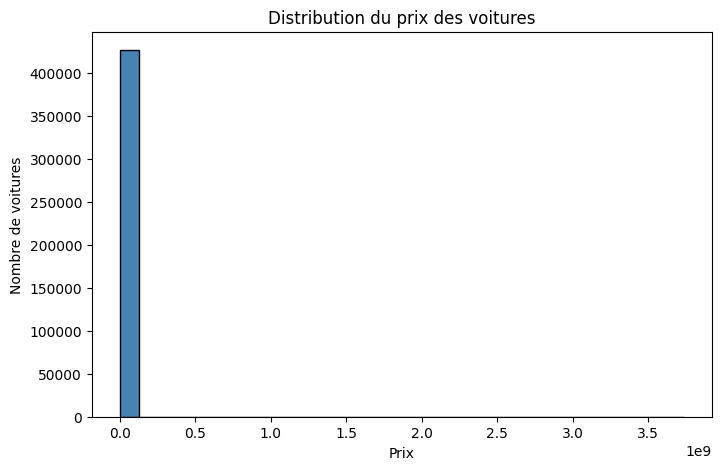

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution du prix des voitures")
plt.xlabel("Prix")
plt.ylabel("Nombre de voitures")
plt.show()

In [8]:
#prix supérieur à 1 000 000
(df[df["price"] > 1_000_000]).shape[0]

53

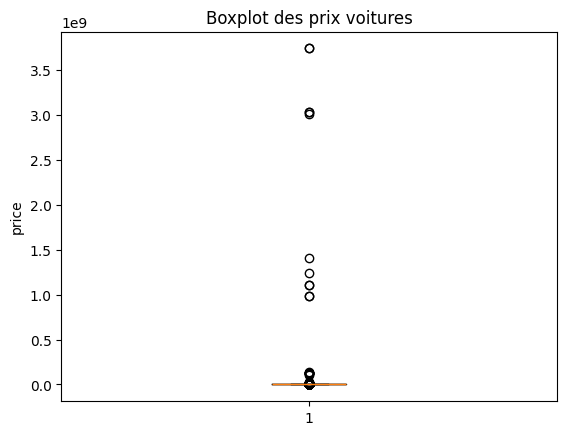

In [9]:
import matplotlib.pyplot as plt

plt.boxplot(df["price"])

plt.ylabel("price")
plt.title("Boxplot des prix voitures")

plt.show()

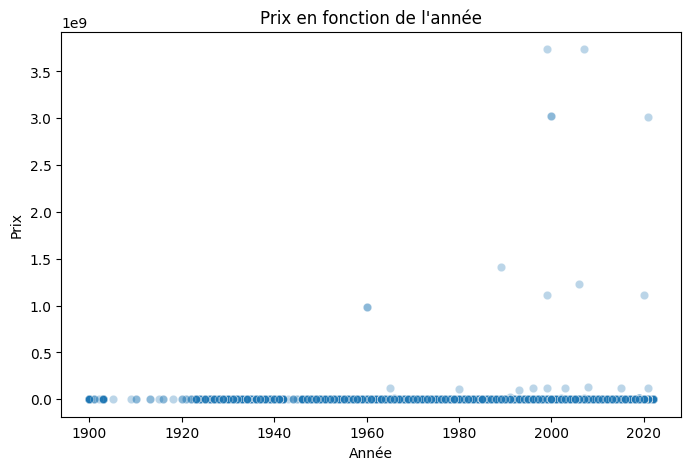

In [10]:
#influence prix et année 

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="year", y="price", alpha=0.3)
plt.title("Prix en fonction de l'année")
plt.xlabel("Année")
plt.ylabel("Prix")
plt.show()

In [11]:
#matrice de correlation
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,id,price,year,odometer,county,lat,long
id,1.000000,-0.002779,-0.059040,0.010721,NaN,-0.069388,-0.121864
price,-0.002779,1.000000,-0.004925,0.010032,NaN,0.000357,-0.000408
year,-0.059040,-0.004925,1.000000,-0.157215,NaN,-0.014677,-0.001410
odometer,0.010721,0.010032,-0.157215,1.000000,NaN,-0.001459,0.009807
county,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,-0.069388,0.000357,-0.014677,-0.001459,NaN,1.000000,-0.128088
long,-0.121864,-0.000408,-0.001410,0.009807,NaN,-0.128088,1.000000
